**Why supervised learning?**
The target variable GY is available for every observation.

**Why regression?**
GY is a continuous numerical variable measured in kg/ha.

**Why not classification?**
There are no natural categorical yield labels. Converting yield
to low, medium and high categories would lose numerical detail.

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import (GridSearchCV, GroupShuffleSplit,train_test_split)
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge

RANDOM_STATE = 42

In [2]:
df = pd.read_csv("soybean_dataset.csv")

In [3]:
print("Dataset Shape")
print("Number of rows    : ", df.shape[0])
print("Number of columns : ", df.shape[1])

Dataset Shape
Number of rows    :  320
Number of columns :  11


Number of unique cultivars

In [4]:
print("Cultivar Information")
print("Number of unique cultivars :", df['Cultivar'].nunique())


Cultivar Information
Number of unique cultivars : 40


In [5]:
print("Cultivars:")
print(sorted(df['Cultivar'].unique()))

Cultivars:
['74K75RSF CE', '77HO111I2X - GUAPORÉ', '79I81RSF IPRO', '82HO111 IPRO - HO COXIM IPRO', '82I78RSF IPRO', '83IX84RSF I2X', '96R29 IPRO', '97Y97 IPRO', '98R30 CE', 'ADAPTA LTT 8402 IPRO', 'ATAQUE I2X', 'BRASMAX BÔNUS IPRO', 'BRASMAX OLIMPO IPRO', 'ELISA IPRO', 'EXPANDE LTT 8301 IPRO', 'FORTALECE L090183 RR', 'FORTALEZA IPRO', 'FTR 3179 IPRO', 'FTR 3190 IPRO', 'FTR 3868 IPRO', 'FTR 4280 IPRO', 'FTR 4288 IPRO', 'GNS7700 IPRO', 'GNS7900 IPRO - AMPLA', 'LAT 1330BT', 'LTT 7901 IPRO', 'LYNDA IPRO', 'M 8644 IPRO', 'MANU IPRO', 'MONSOY 8330I2X', 'MONSOY M8606I2X', 'NEO 760 CE', 'NEO 790 IPRO', 'NK 7777 IPRO', 'NK 8100 IPRO', 'NK 8770 IPRO', 'PAULA IPRO', 'SUZY IPRO', 'SYN2282IPRO', 'TMG 22X83I2X']


In [6]:
print("Season Information")
print("Number of unique seasons : ",df['Season'].nunique())

Season Information
Number of unique seasons :  2


In [7]:
print("Season values:")
print(sorted(df['Season'].unique()))

Season values:
[np.int64(1), np.int64(2)]


In [8]:
print("Missing Values Per Column")
print(df.isnull().sum())

print("Total Missing Values in Dataset:", df.isnull().sum().sum())

Missing Values Per Column
Season        0
Cultivar      0
Repetition    0
PH            0
IFP           0
NLP           0
NGP           0
NGL           0
NS            0
MHG           0
GY            0
dtype: int64
Total Missing Values in Dataset: 0


Distribution of Soybean Grain Yield

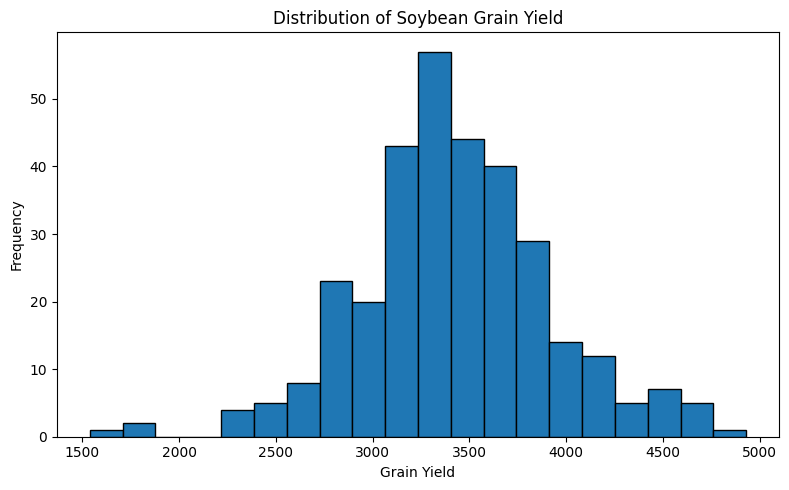

In [11]:
plt.figure(figsize=(8, 5))
plt.hist(df["GY"], bins=20, edgecolor="black")
plt.xlabel("Grain Yield")
plt.ylabel("Frequency")
plt.title("Distribution of Soybean Grain Yield")
plt.tight_layout()
plt.show()

Grain Yield by Season

<Figure size 800x500 with 0 Axes>

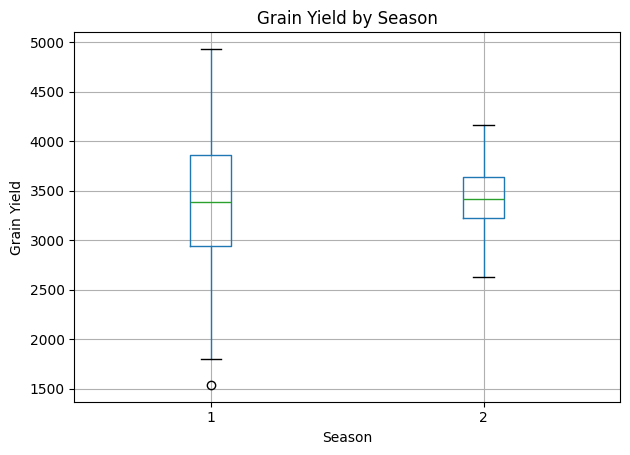

In [12]:
plt.figure(figsize=(8, 5))
df.boxplot(column="GY", by="Season")
plt.xlabel("Season")
plt.ylabel("Grain Yield")
plt.title("Grain Yield by Season")
plt.suptitle("")
plt.tight_layout()
plt.show()

Correlation matrix for numerical variables

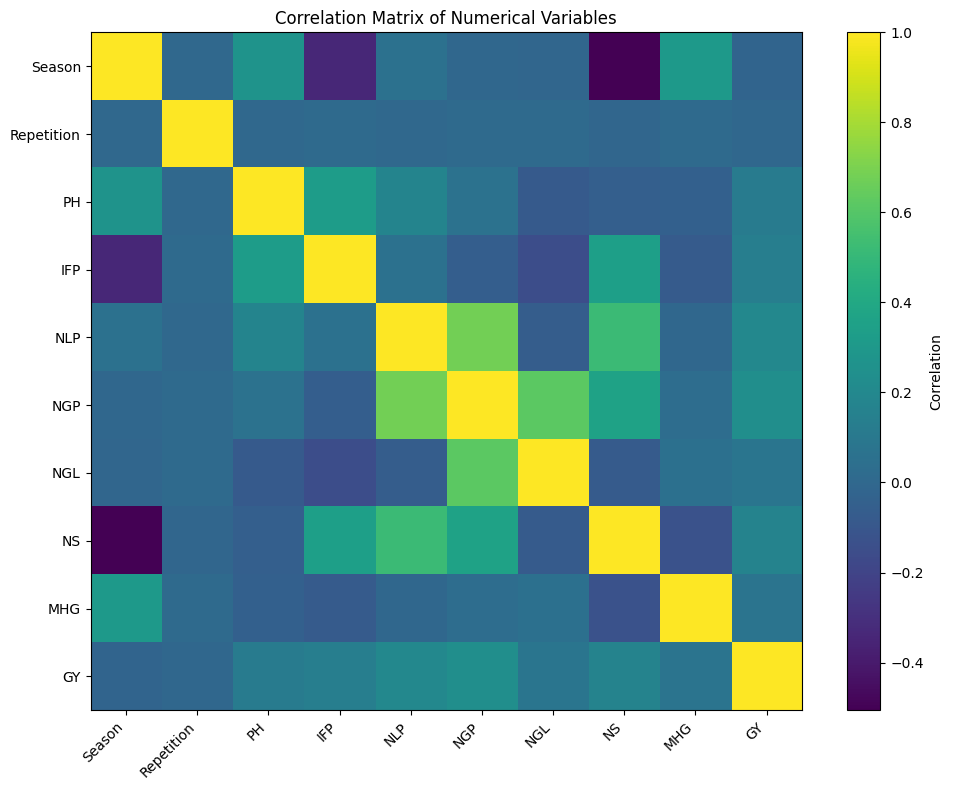

In [13]:
numeric_df = df.select_dtypes(include=np.number)
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(10, 8))
plt.imshow(correlation_matrix, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha="right"
)
plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)
plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()

Data Encoding and Scaling

In [15]:
X = df.drop(columns=["GY"])
y = df["GY"]

Convert cultivar into numerical column

In [17]:
X_encoded = pd.get_dummies(X, columns=["Cultivar"],drop_first=False,dtype=int)
print(X_encoded.head())

   Season  Repetition     PH    IFP    NLP     NGP   NGL   NS     MHG  \
0       1           1  58.80  15.20   98.2  177.80  1.81  5.2  152.20   
1       1           2  58.60  13.40  102.0  195.00  1.85  7.2  141.69   
2       1           3  63.40  17.20  100.4  203.00  2.02  6.8  148.81   
3       1           4  60.27  15.27  100.2  191.93  1.89  6.4  148.50   
4       1           1  81.20  18.00   98.8  173.00  1.75  7.4  145.59   

   Cultivar_74K75RSF CE  ...  Cultivar_MONSOY M8606I2X  Cultivar_NEO 760 CE  \
0                     0  ...                         0                    1   
1                     0  ...                         0                    1   
2                     0  ...                         0                    1   
3                     0  ...                         0                    1   
4                     0  ...                         0                    0   

   Cultivar_NEO 790 IPRO  Cultivar_NK 7777 IPRO  Cultivar_NK 8100 IPRO  \
0           

function for caling training and test which i will use in different type of split as well

In [19]:
def scale_data(X_train, X_test):
    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    return X_train_scaled, X_test_scaled

as every model have same functions of predict so i am going to create single function that will help in prediction and calculate result using mean_squared error and r2 score

In [20]:
def calculate_results(split_name, model_name, model, X_train, X_test, y_train, y_test, best_parameters):
    train_predictions = model.predict(X_train)
    test_predictions = model.predict(X_test)

    train_mae = mean_absolute_error(y_train,train_predictions)

    test_mae = mean_absolute_error(y_test,test_predictions)

    train_rmse = np.sqrt(mean_squared_error(y_train,train_predictions))

    test_rmse = np.sqrt(mean_squared_error(y_test, test_predictions))

    train_r2 = r2_score(y_train,train_predictions)

    test_r2 = r2_score(y_test,test_predictions)

    print("\n", split_name, "-", model_name)
    print("Best parameters:", best_parameters)
    print("Train MAE:", round(train_mae, 2))
    print("Test MAE:", round(test_mae, 2))
    print("Train RMSE:", round(train_rmse, 2))
    print("Test RMSE:", round(test_rmse, 2))
    print("Train R2:", round(train_r2, 3))
    print("Test R2:", round(test_r2, 3))

    result = {
        "Split": split_name,
        "Model": model_name,
        "Best Parameters": str(best_parameters),
        "Train MAE": train_mae,
        "Test MAE": test_mae,
        "Train RMSE": train_rmse,
        "Test RMSE": test_rmse,
        "RMSE Gap": test_rmse - train_rmse,
        "Train R2": train_r2,
        "Test R2": test_r2
    }

    prediction_table = pd.DataFrame({
        "Split": split_name,
        "Model": model_name,
        "Actual GY": y_test.to_numpy(),
        "Predicted GY": test_predictions,
        "Residual": y_test.to_numpy() - test_predictions
    })

    return result, prediction_table

i am goin to perform my expermients by using 3 types of split, 1st split is 80/20 split and then 70/30 split on train and test data and 3rd and last is on Cultivar Holdout

80/20 split of dataset

In [24]:
X_train_80, X_test_80, y_train_80, y_test_80 = train_test_split(X_encoded, y, test_size=0.20, random_state=RANDOM_STATE)

X_train_80_scaled, X_test_80_scaled = scale_data(X_train_80, X_test_80)

70/30 split of dataset

In [25]:
X_train_70, X_test_70, y_train_70, y_test_70 = train_test_split( X_encoded, y, test_size=0.30, random_state=RANDOM_STATE)

X_train_70_scaled, X_test_70_scaled = scale_data(X_train_70, X_test_70)

Cultivar Holdout dataset split

In [26]:
group_splitter = GroupShuffleSplit( n_splits=1, test_size=0.20, random_state=RANDOM_STATE)

train_index, test_index = next(group_splitter.split(X_encoded, y, groups=df["Cultivar"]))

X_train_cultivar = X_encoded.iloc[train_index]
X_test_cultivar = X_encoded.iloc[test_index]

y_train_cultivar = y.iloc[train_index]
y_test_cultivar = y.iloc[test_index]

X_train_cultivar_scaled, X_test_cultivar_scaled = scale_data(X_train_cultivar, X_test_cultivar)

print("Number of training cultivars:", df.iloc[train_index]["Cultivar"].nunique())

print("Number of testing cultivars:", df.iloc[test_index]["Cultivar"].nunique())

Number of training cultivars: 32
Number of testing cultivars: 8


In [27]:
results = []
prediction_tables = []

Using Random forest find best parameters using GridSearchCV on 80/20 dataset and calculate result using already defined function

In [29]:
random_forest_parameters = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

random_forest_grid_80 = GridSearchCV(
    estimator=RandomForestRegressor(
        random_state=RANDOM_STATE
    ),
    param_grid=random_forest_parameters,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1
)

random_forest_grid_80.fit(
    X_train_80,
    y_train_80
)

best_random_forest_80 = (
    random_forest_grid_80.best_estimator_
)

rf_result_80, rf_predictions_80 = calculate_results(
    split_name="Random 80/20",
    model_name="Random Forest",
    model=best_random_forest_80,
    X_train=X_train_80,
    X_test=X_test_80,
    y_train=y_train_80,
    y_test=y_test_80,
    best_parameters=random_forest_grid_80.best_params_
)

results.append(rf_result_80)
prediction_tables.append(rf_predictions_80)


 Random 80/20 - Random Forest
Best parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Train MAE: 106.54
Test MAE: 283.93
Train RMSE: 141.61
Test RMSE: 357.95
Train R2: 0.92
Test R2: 0.505


Using Random forest find best parameters using GridSearchCV on 70/30 dataset and calculate result using already defined function

In [30]:
random_forest_grid_70 = GridSearchCV(
    RandomForestRegressor(
        random_state=RANDOM_STATE
    ),
    random_forest_parameters,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1
)

random_forest_grid_70.fit(
    X_train_70,
    y_train_70
)

best_random_forest_70 = (
    random_forest_grid_70.best_estimator_
)

rf_result_70, rf_predictions_70 = calculate_results(
    "Random 70/30",
    "Random Forest",
    best_random_forest_70,
    X_train_70,
    X_test_70,
    y_train_70,
    y_test_70,
    random_forest_grid_70.best_params_
)

results.append(rf_result_70)
prediction_tables.append(rf_predictions_70)


 Random 70/30 - Random Forest
Best parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Train MAE: 107.04
Test MAE: 311.71
Train RMSE: 142.03
Test RMSE: 416.54
Train R2: 0.917
Test R2: 0.362


Using Random forest find best parameters using GridSearchCV on cultivar holdout dataset and calculate result using already defined function

In [31]:
random_forest_grid_cultivar = GridSearchCV(
    RandomForestRegressor(
        random_state=RANDOM_STATE
    ),
    random_forest_parameters,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1
)

random_forest_grid_cultivar.fit(
    X_train_cultivar,
    y_train_cultivar
)

best_random_forest_cultivar = (
    random_forest_grid_cultivar.best_estimator_
)

rf_result_cultivar, rf_predictions_cultivar = calculate_results(
    "Cultivar holdout 80/20",
    "Random Forest",
    best_random_forest_cultivar,
    X_train_cultivar,
    X_test_cultivar,
    y_train_cultivar,
    y_test_cultivar,
    random_forest_grid_cultivar.best_params_
)

results.append(rf_result_cultivar)
prediction_tables.append(rf_predictions_cultivar)


 Cultivar holdout 80/20 - Random Forest
Best parameters: {'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 300}
Train MAE: 271.18
Test MAE: 477.21
Train RMSE: 344.8
Test RMSE: 611.04
Train R2: 0.503
Test R2: -0.304


Feature selection

In [54]:
feature_importance = pd.DataFrame({
    "Feature": X_train_80.columns,
    "Importance": best_random_forest_80.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

                                  Feature  Importance
15                    Cultivar_96R29 IPRO    0.127501
8                                     MHG    0.125502
3                                     IFP    0.103233
7                                      NS    0.101983
5                                     NGP    0.098801
4                                     NLP    0.068446
6                                     NGL    0.067494
2                                      PH    0.063906
0                                  Season    0.031861
17                      Cultivar_98R30 CE    0.027203
38                Cultivar_MONSOY 8330I2X    0.022645
13                 Cultivar_82I78RSF IPRO    0.020334
26                 Cultivar_FTR 3179 IPRO    0.019974
18          Cultivar_ADAPTA LTT 8402 IPRO    0.019856
9                    Cultivar_74K75RSF CE    0.009898
1                              Repetition    0.009181
16                    Cultivar_97Y97 IPRO    0.008919
11                 Cultivar_

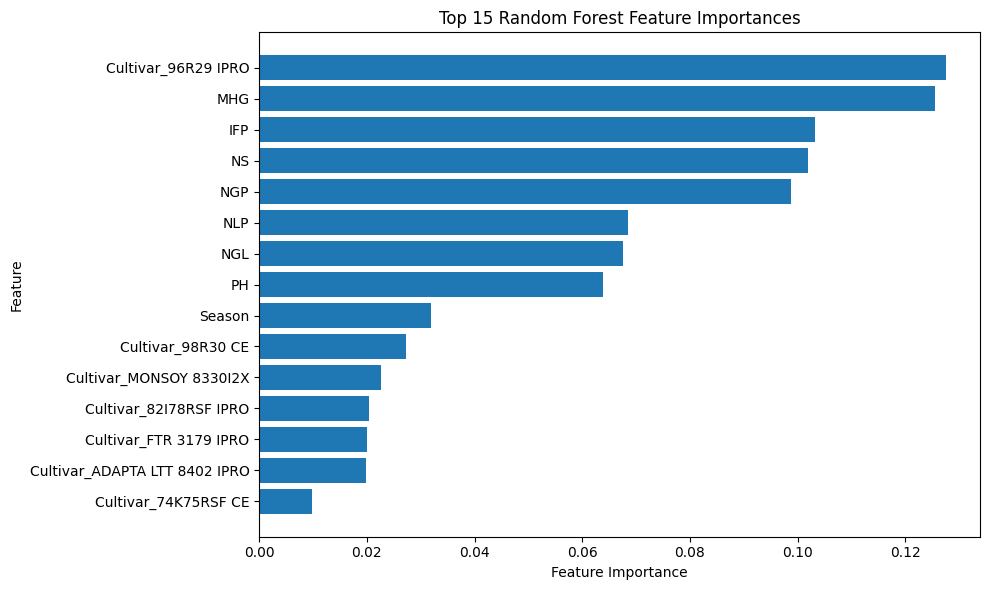

In [55]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))
plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Random Forest Feature Importances")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Using ridge regression find best parameters using GridSearchCV on 80/20 dataset and calculate result using already defined function


In [32]:
ridge_parameters = {
    "alpha": [0.01, 0.1, 1, 10, 50, 100, 200]
}

ridge_grid_80 = GridSearchCV(
    estimator=Ridge(),
    param_grid=ridge_parameters,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1
)

ridge_grid_80.fit(
    X_train_80_scaled,
    y_train_80
)

best_ridge_80 = ridge_grid_80.best_estimator_

ridge_result_80, ridge_predictions_80 = calculate_results(
    split_name="Random 80/20",
    model_name="Ridge",
    model=best_ridge_80,
    X_train=X_train_80_scaled,
    X_test=X_test_80_scaled,
    y_train=y_train_80,
    y_test=y_test_80,
    best_parameters=ridge_grid_80.best_params_
)

results.append(ridge_result_80)
prediction_tables.append(ridge_predictions_80)


 Random 80/20 - Ridge
Best parameters: {'alpha': 50}
Train MAE: 263.77
Test MAE: 283.58
Train RMSE: 332.05
Test RMSE: 358.14
Train R2: 0.56
Test R2: 0.505


Using ridge regression find best parameters using GridSearchCV on 70/30 dataset and calculate result using already defined function

In [33]:
ridge_grid_70 = GridSearchCV(
    Ridge(),
    {"alpha": [0.01, 0.1, 1, 10, 50, 100, 200]},
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1
)

ridge_grid_70.fit(
    X_train_70_scaled,
    y_train_70
)

best_ridge_70 = ridge_grid_70.best_estimator_

ridge_result_70, ridge_predictions_70 = calculate_results(
    "Random 70/30",
    "Ridge",
    best_ridge_70,
    X_train_70_scaled,
    X_test_70_scaled,
    y_train_70,
    y_test_70,
    ridge_grid_70.best_params_
)

results.append(ridge_result_70)
prediction_tables.append(ridge_predictions_70)


 Random 70/30 - Ridge
Best parameters: {'alpha': 50}
Train MAE: 255.05
Test MAE: 308.25
Train RMSE: 328.51
Test RMSE: 395.92
Train R2: 0.556
Test R2: 0.424


Using ridge regression find best parameters using GridSearchCV on cultivar holdout dataset and calculate result using already defined function

In [34]:
ridge_grid_cultivar = GridSearchCV(
    Ridge(),
    {"alpha": [0.01, 0.1, 1, 10, 50, 100, 200]},
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1
)

ridge_grid_cultivar.fit(
    X_train_cultivar_scaled,
    y_train_cultivar
)

best_ridge_cultivar = (
    ridge_grid_cultivar.best_estimator_
)

ridge_result_cultivar, ridge_predictions_cultivar = calculate_results(
    "Cultivar holdout 80/20",
    "Ridge",
    best_ridge_cultivar,
    X_train_cultivar_scaled,
    X_test_cultivar_scaled,
    y_train_cultivar,
    y_test_cultivar,
    ridge_grid_cultivar.best_params_
)

results.append(ridge_result_cultivar)
prediction_tables.append(ridge_predictions_cultivar)


 Cultivar holdout 80/20 - Ridge
Best parameters: {'alpha': 200}
Train MAE: 276.22
Test MAE: 426.19
Train RMSE: 366.11
Test RMSE: 534.67
Train R2: 0.44
Test R2: 0.001


Actual vs Predicted Grain Yield – Ridge Regression

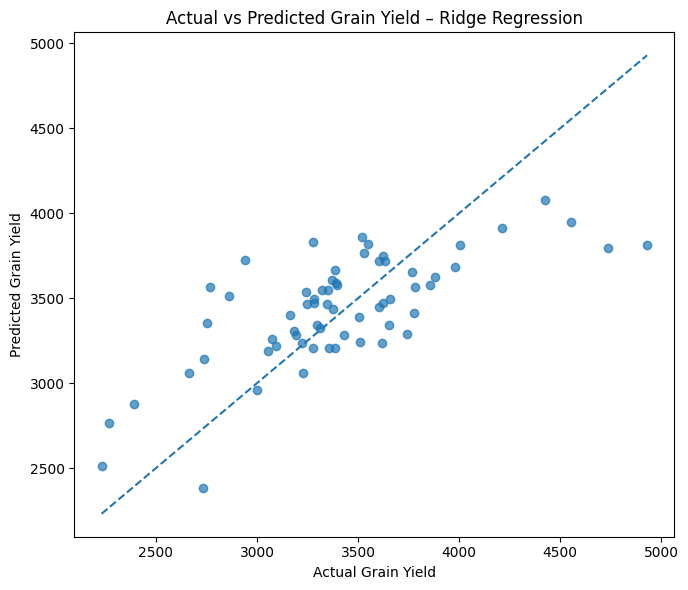

In [56]:
plt.figure(figsize=(7, 6))

plt.scatter(
    ridge_predictions_80["Actual GY"],
    ridge_predictions_80["Predicted GY"],
    alpha=0.7
)

minimum_value = min(
    ridge_predictions_80["Actual GY"].min(),
    ridge_predictions_80["Predicted GY"].min()
)

maximum_value = max(
    ridge_predictions_80["Actual GY"].max(),
    ridge_predictions_80["Predicted GY"].max()
)

plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle="--"
)

plt.xlabel("Actual Grain Yield")
plt.ylabel("Predicted Grain Yield")
plt.title("Actual vs Predicted Grain Yield – Ridge Regression")
plt.tight_layout()
plt.show()

In [35]:
gradient_boosting_parameters = {
    "n_estimators": [60, 100, 200],
    "learning_rate": [0.03, 0.05, 0.1],
    "max_depth": [2, 3, 4],
    "min_samples_split": [2, 5, 10],
    "subsample": [0.7, 0.85, 1.0]
}

gradient_boosting_grid_80 = GridSearchCV(
    estimator=GradientBoostingRegressor(
        random_state=RANDOM_STATE
    ),
    param_grid=gradient_boosting_parameters,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1
)

gradient_boosting_grid_80.fit(
    X_train_80,
    y_train_80
)

best_gradient_boosting_80 = (
    gradient_boosting_grid_80.best_estimator_
)

gb_result_80, gb_predictions_80 = calculate_results(
    split_name="Random 80/20",
    model_name="Gradient Boosting",
    model=best_gradient_boosting_80,
    X_train=X_train_80,
    X_test=X_test_80,
    y_train=y_train_80,
    y_test=y_test_80,
    best_parameters=gradient_boosting_grid_80.best_params_
)

results.append(gb_result_80)
prediction_tables.append(gb_predictions_80)


 Random 80/20 - Gradient Boosting
Best parameters: {'learning_rate': 0.1, 'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 200, 'subsample': 1.0}
Train MAE: 86.39
Test MAE: 249.63
Train RMSE: 115.24
Test RMSE: 315.52
Train R2: 0.947
Test R2: 0.616


In [36]:
gradient_boosting_grid_70 = GridSearchCV(
    GradientBoostingRegressor(
        random_state=RANDOM_STATE
    ),
    gradient_boosting_parameters,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1
)

gradient_boosting_grid_70.fit(
    X_train_70,
    y_train_70
)

best_gradient_boosting_70 = (
    gradient_boosting_grid_70.best_estimator_
)

gb_result_70, gb_predictions_70 = calculate_results(
    "Random 70/30",
    "Gradient Boosting",
    best_gradient_boosting_70,
    X_train_70,
    X_test_70,
    y_train_70,
    y_test_70,
    gradient_boosting_grid_70.best_params_
)

results.append(gb_result_70)
prediction_tables.append(gb_predictions_70)


 Random 70/30 - Gradient Boosting
Best parameters: {'learning_rate': 0.1, 'max_depth': 4, 'min_samples_split': 2, 'n_estimators': 200, 'subsample': 0.7}
Train MAE: 30.21
Test MAE: 281.49
Train RMSE: 35.73
Test RMSE: 395.03
Train R2: 0.995
Test R2: 0.426


In [37]:
gradient_boosting_grid_cultivar = GridSearchCV(
    GradientBoostingRegressor(
        random_state=RANDOM_STATE
    ),
    gradient_boosting_parameters,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1
)

gradient_boosting_grid_cultivar.fit(
    X_train_cultivar,
    y_train_cultivar
)

best_gradient_boosting_cultivar = (
    gradient_boosting_grid_cultivar.best_estimator_
)

gb_result_cultivar, gb_predictions_cultivar = calculate_results(
    "Cultivar holdout 80/20",
    "Gradient Boosting",
    best_gradient_boosting_cultivar,
    X_train_cultivar,
    X_test_cultivar,
    y_train_cultivar,
    y_test_cultivar,
    gradient_boosting_grid_cultivar.best_params_
)

results.append(gb_result_cultivar)
prediction_tables.append(gb_predictions_cultivar)


 Random 70/30 - Gradient Boosting
Best parameters: {'learning_rate': 0.1, 'max_depth': 4, 'min_samples_split': 2, 'n_estimators': 200, 'subsample': 0.7}
Train MAE: 30.21
Test MAE: 281.49
Train RMSE: 35.73
Test RMSE: 395.03
Train R2: 0.995
Test R2: 0.426


In [49]:
results_df = pd.DataFrame(results)

predictions_df = pd.concat(prediction_tables, ignore_index=True)

results_df = results_df.sort_values(["Split", "Test RMSE"]).reset_index(drop=True)

print("Detailed model results:")
print(results_df.round(3).to_string(index=False))

results_df.to_csv("detailed_model_results.csv", index=False)

predictions_df.to_csv("test_predictions.csv",index=False)

Detailed model results:
                 Split             Model                                                                                       Best Parameters  Train MAE  Test MAE  Train RMSE  Test RMSE  RMSE Gap  Train R2  Test R2
Cultivar holdout 80/20             Ridge                                                                                        {'alpha': 200}    276.217   426.189     366.109    534.668   168.558     0.440    0.001
Cultivar holdout 80/20     Random Forest                 {'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 300}    271.180   477.214     344.800    611.039   266.239     0.503   -0.304
          Random 70/30 Gradient Boosting {'learning_rate': 0.1, 'max_depth': 4, 'min_samples_split': 2, 'n_estimators': 200, 'subsample': 0.7}     30.209   281.489      35.730    395.026   359.295     0.995    0.426
          Random 70/30 Gradient Boosting {'learning_rate': 0.1, 'max_depth': 4, 'min_samples_split': 2, 'n_estim

Model Stability Summary

In [48]:
summary_df = (
    results_df
    .groupby("Model")
    .agg(
        Mean_Test_MAE=("Test MAE", "mean"),
        Mean_Test_RMSE=("Test RMSE", "mean"),
        SD_Test_RMSE=("Test RMSE", "std"),
        Mean_Test_R2=("Test R2", "mean"),
        SD_Test_R2=("Test R2", "std"),
        Mean_RMSE_Gap=("RMSE Gap", "mean")
    )
    .sort_values("Mean_Test_RMSE")
    .reset_index()
)

print("Average performance:")
print(summary_df.round(3).to_string(index=False))

summary_df.to_csv("model_stability_summary.csv", index=False)

Average performance:
            Model  Mean_Test_MAE  Mean_Test_RMSE  SD_Test_RMSE  Mean_Test_R2  SD_Test_R2  Mean_RMSE_Gap
Gradient Boosting        270.871         368.523        45.904         0.489       0.109        306.288
            Ridge        339.339         429.577        92.951         0.310       0.270         87.352
    Random Forest        357.619         461.841       132.489         0.188       0.432        252.359


Test dataset RMSE Comparison

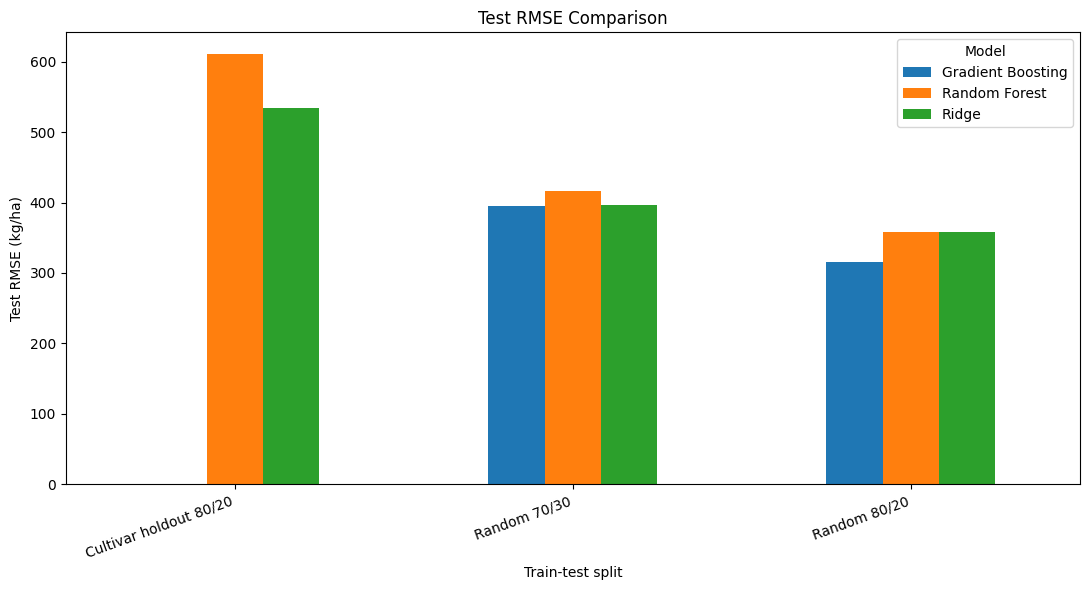

In [50]:
results_df = results_df.drop_duplicates(subset=["Split", "Model"],keep="last").reset_index(drop=True)

rmse_table = results_df.pivot(index="Split", columns="Model", values="Test RMSE")

rmse_table.plot(kind="bar", figsize=(11, 6))

plt.xlabel("Train-test split")
plt.ylabel("Test RMSE (kg/ha)")
plt.title("Test RMSE Comparison")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

Test Dataset R2 Comparison

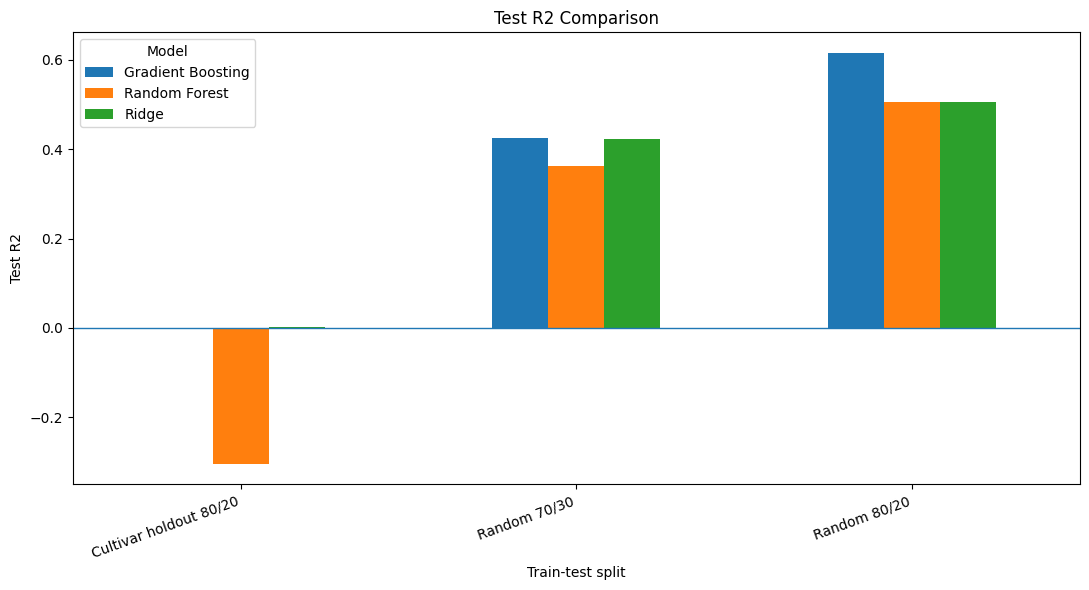

In [51]:
r2_table = results_df.pivot(index="Split", columns="Model", values="Test R2")

r2_table.plot(kind="bar", figsize=(11, 6))

plt.axhline(0, linewidth=1)

plt.xlabel("Train-test split")
plt.ylabel("Test R2")
plt.title("Test R2 Comparison")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

Training and Testing RMSE

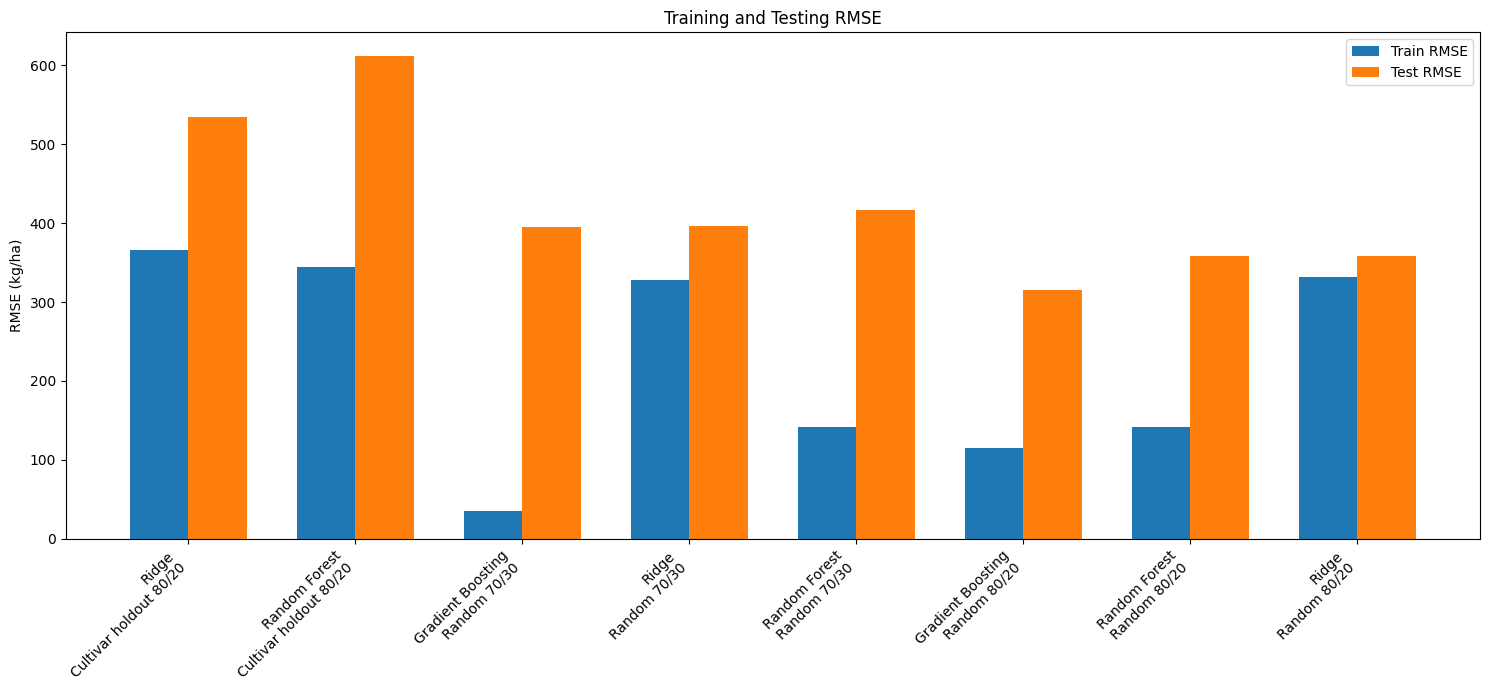

In [52]:
chart_data = results_df.copy()

chart_data["Label"] = (chart_data["Model"]+ "\n" + chart_data["Split"])

positions = np.arange(len(chart_data))
width = 0.35

plt.figure(figsize=(15, 7))

plt.bar(
    positions - width / 2,
    chart_data["Train RMSE"],
    width=width,
    label="Train RMSE"
)

plt.bar(
    positions + width / 2,
    chart_data["Test RMSE"],
    width=width,
    label="Test RMSE"
)

plt.xticks(
    positions,
    chart_data["Label"],
    rotation=45,
    ha="right"
)

plt.ylabel("RMSE (kg/ha)")
plt.title("Training and Testing RMSE")
plt.legend()
plt.tight_layout()
plt.show()